In [1]:
from keras.layers import Lambda, Input, Dense, Reshape, Dropout, Conv2D, Flatten
from keras.models import Model
from keras.losses import mse, binary_crossentropy
from keras.utils import plot_model

from keras.metrics import categorical_crossentropy

import tensorflow as tf
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split, KFold
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, mean_squared_error

import pandas as pd
import numpy as np
import xarray as xr

from scipy import stats
from math import ceil

import matplotlib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import seaborn as sns

import clustering_functions as cf
import skill_functions as sf          # NOTE: alias is 'sf', not 'sc'
import preprocessing_functions as pf

In [2]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]

#### Parameters

In [3]:
import yaml

# Key settings for MSWEP run
cluster_number          = 5
reconstruction_loss_factor = 0.5
filepath                = "results/cmmvae_mswep/"

pr_cluster_number       = 5

# Z500 Atlantic grid dimensions (unchanged from original: 25 lat x 33 lon = 825)
original_dim = 825
inputdim1    = 25
inputdim2    = 33

latent_dim          = 15
activation_function = 'relu'
dim_layer1          = 256
dim_layer2          = 128
dim_layer3          = 64
cat_dim             = 1
batch_size          = 128
epochs              = 100   # 100 as requested

input_shape   = (original_dim,)
input_shape_r = (pr_cluster_number,)

### Sampling function

In [4]:
def sampling(args):
    z_mean, z_log_sigma = args
    epsilon = K.random_normal(
        shape=(K.shape(z_mean)[0], K.int_shape(z_mean)[1]),
        mean=0., stddev=1.)
    return z_mean + K.exp(0.5 * z_log_sigma) * epsilon

### Data pre-processing

In [5]:
# Load ERA5 Z500 geopotential height (Atlantic region, extended winter)
z500 = pf.preprocess_dataset(
    filename            = '../data.nosync/era5_z500_daily_250_atlantic_1940_2022.nc',
    variable_name       = 'z',
    multiplication_factor = 1 / g0,
    geographical_filter = 'new atlantic',
    months_filter       = extended_winter_months,
    anomalies           = True,
    normalization       = False,
    rolling_window      = 5)

# Restrict to MSWEP period: 1979–2020
z500 = z500.where(z500['time.year'] > 1978, drop=True)
z500 = z500.where(z500['time.year'] < 2021, drop=True)

# Area weighting by cosine of latitude and standardisation
weights = np.cos(np.deg2rad(z500.latitude))
z500    = z500 * weights
z500    = z500 / z500.std()

z500_reshaped = cf.reshape_data_for_clustering(z500)
print(f"Z500 shape: {z500.shape}  →  reshaped: {z500_reshaped.shape}")

Z500 shape: (6353, 25, 33)  →  reshaped: (6353, 825)


In [6]:
# Load MSWEP precipitation cluster labels (generated by generate_mswep_files.py)
pr_labels = pd.read_csv('../data.nosync/MSWEP_pr_cluster_labels_5.csv')
pr_labels.columns = ['index', 'labels']

# Build one-hot label matrix  shape: (n_days, pr_cluster_number)
pr_labels['values'] = 1
label_indices_pd = pd.pivot_table(
    pr_labels, values='values', index=['index'],
    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

# Load 95th-percentile exceedance binary mask
threshold_qn95 = xr.open_dataset('../data.nosync/MSWEP_pr_95pc_EW.nc')
threshold_qn95 = threshold_qn95.where(
    threshold_qn95['time.year'] < 2021, drop=True)['precipitation']

# Load total precipitation (for cluster reordering & odds ratio)
pr_spatial = xr.open_dataset('../data.nosync/MSWEP_pr_total_EW.nc')['precipitation']
pr_spatial = pr_spatial.where(pr_spatial['time.year'] < 2021, drop=True)

print(f"Cluster label matrix: {label_indices.shape}")
print(f"Threshold mask shape: {threshold_qn95.shape}")
print(f"pr_spatial shape:     {pr_spatial.shape}")

# Sanity check: Z500 and target must have the same number of time steps
assert z500.shape[0] == label_indices.shape[0], (
    f"Time mismatch! Z500={z500.shape[0]}, labels={label_indices.shape[0]}")
print("Time alignment OK.")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4116\4116172297.py:7: FutureWarning: The provided callable <function sum at 0x000002148995AA70> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  label_indices_pd = pd.pivot_table(


Cluster label matrix: (6353, 5)
Threshold mask shape: (6353, 150, 160)
pr_spatial shape:     (6353, 150, 160)
Time alignment OK.


## Define model

**Encoder**

In [7]:
inputs_x  = Input(shape=input_shape,   name='encoder_input')
inputs_r  = Input(shape=input_shape_r, name='ground_truth')

inter_x1  = Dense(dim_layer1, activation=activation_function, name='encoder_intermediate')(inputs_x)
inter_x2  = Dense(dim_layer2, activation=activation_function, name='encoder_intermediate_2')(inter_x1)
inter_x3  = Dense(dim_layer3, activation=activation_function, name='encoder_intermediate_3')(inter_x2)

dummy      = Input(shape=(1,), name='dummy')
mu_vector  = Dense(cluster_number * latent_dim, name='mu_vector', use_bias=False)(dummy)
mu         = Reshape((cluster_number, latent_dim), name='mu')(mu_vector)

pi  = Dense(cluster_number, activation='softmax', name='pi')(dummy)
c   = Dense(cluster_number, activation='softmax', name='c')(inter_x3)

z_mean    = Dense(latent_dim, name='z_mean')(inter_x3)
z_log_var = Dense(latent_dim, name='z_log_var')(inter_x3)

r  = Dense(pr_cluster_number, name='r_label', activation='softmax')(inter_x3)
cr = Dense(cluster_number,    activation='softmax', name='cr')(r)

z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

encoder = Model(
    [inputs_x, dummy, inputs_r],
    [z_mean, z_log_var, z, mu, c, pi, r, cr],
    name='encoder')

encoder.summary()


Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 825)]                0         []                            
                                                                                                  
 encoder_intermediate (Dens  (None, 256)                  211456    ['encoder_input[0][0]']       
 e)                                                                                               
                                                                                                  
 encoder_intermediate_2 (De  (None, 128)                  32896     ['encoder_intermediate[0][0]']
 nse)                                                                                             
                                                                                           

**Decoder**

In [8]:
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')

inter_y1 = Dense(dim_layer3, activation=activation_function)(latent_inputs)
inter_y2 = Dense(dim_layer2, activation=activation_function)(inter_y1)
inter_y3 = Dense(dim_layer1, activation=activation_function)(inter_y2)

outputs  = Dense(original_dim)(inter_y3)

decoder  = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_sampling (InputLayer)     [(None, 15)]              0         
                                                                 
 dense (Dense)               (None, 64)                1024      
                                                                 
 dense_1 (Dense)             (None, 128)               8320      
                                                                 
 dense_2 (Dense)             (None, 256)               33024     
                                                                 
 dense_3 (Dense)             (None, 825)               212025    
                                                                 
Total params: 254393 (993.72 KB)
Trainable params: 254393 (993.72 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Combine encoder and decoder into the VAE model**

In [9]:
outputs = decoder(encoder([inputs_x, dummy, inputs_r])[2])
vae     = Model([inputs_x, dummy, inputs_r], outputs, name='vae_classification')
vae.summary()

Model: "vae_classification"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 825)]                0         []                            
                                                                                                  
 dummy (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 ground_truth (InputLayer)   [(None, 5)]                  0         []                            
                                                                                                  
 encoder (Functional)        [(None, 15),                 255323    ['encoder_input[0][0]',       
                              (None, 15),                            'dummy[0][0]

### Loss function

In [10]:
reconstruction_loss = mse(inputs_x, outputs) * original_dim * reconstruction_loss_factor
prediction_loss     = categorical_crossentropy(c, cr)
target_loss         = (categorical_crossentropy(inputs_r, r) +
                       categorical_crossentropy(r, r)) * pr_cluster_number

kl_loss_all  = tf.compat.v1.get_variable(
    "kl_loss_all", [batch_size, 1], dtype=tf.float32,
    initializer=tf.zeros_initializer)
kl_cat_all   = tf.compat.v1.get_variable(
    "kl_cat_all", [batch_size, 1], dtype=tf.float32,
    initializer=tf.zeros_initializer)
dir_prior_all = tf.compat.v1.get_variable(
    "dir_prior_all", [batch_size, 1], dtype=tf.float32,
    initializer=tf.zeros_initializer)

for i in range(cluster_number):
    kl_loss = 1 + z_log_var - tf.math.square(z_mean - mu[:, i, :]) - tf.math.exp(z_log_var)
    kl_loss = tf.multiply(tf.reduce_sum(kl_loss, axis=-1), c[:, i])
    kl_loss = -0.5 * kl_loss
    kl_loss_all = kl_loss_all + kl_loss

    mc      = tf.reduce_mean(c[:, i])
    mpi     = tf.reduce_mean(pi[:, i])
    kl_cat  = mc * tf.math.log(mc) - mc * tf.math.log(mpi)
    kl_cat_all = kl_cat_all + kl_cat

    dir_prior     = -tf.math.log(pi[:, i]) * 0.5
    dir_prior_all = dir_prior_all + dir_prior

**Compile model and save initial random weights**

In [11]:
vae_loss = K.mean(
    reconstruction_loss + prediction_loss + target_loss +
    kl_loss_all + kl_cat_all + dir_prior_all)

vae.add_loss(vae_loss)
vae.compile(optimizer='adam')
vae.summary()

# Save initial random weights so every fold starts from the same point
vae.save_weights(filepath + 'random_weights_' + str(cluster_number) + '.h5')
print("Random weights saved.")


Model: "vae_classification"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 825)]                0         []                            
                                                                                                  
 dummy (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 ground_truth (InputLayer)   [(None, 5)]                  0         []                            
                                                                                                  
 encoder (Functional)        [(None, 15),                 255323    ['encoder_input[0][0]',       
                              (None, 15),                            'dummy[0][0

## Train model

In [12]:
X          = cf.reshape_data_for_clustering(z500)   # (n_days, 825)
y          = label_indices                              # (n_days, 5)
dummy_full = np.ones((X.shape[0], 1))
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (6353, 825), y shape: (6353, 5)


#### 5-Fold Cross-Validation (100 epochs per fold)

In [13]:
n_splits = 5
kfold    = KFold(n_splits=n_splits, shuffle=True, random_state=42)

best_val_loss = float('inf')
best_fold     = -1

# Will hold cluster-probability predictions on held-out test days
out_of_fold_predictions = np.zeros_like(y, dtype=float)

fold_histories = []   # store loss curves for later plotting

for fold, (train_idx, test_idx) in enumerate(kfold.split(X)):
    print(f"\n--- FOLD {fold + 1}/{n_splits} ---")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    dummy_train = np.ones((X_train.shape[0], 1))
    dummy_test  = np.ones((X_test.shape[0],  1))

    # Reset to identical starting weights
    vae.load_weights(filepath + 'random_weights_' + str(cluster_number) + '.h5')

    history = vae.fit(
        [X_train, dummy_train, y_train],
        [X_train, dummy_train, y_train],
        epochs     = 100,
        batch_size = batch_size,
        validation_data = (
            [X_test, dummy_test, y_test],
            [X_test, dummy_test, y_test]),
        verbose = 0)

    fold_histories.append(history.history)

    # Collect out-of-fold cluster probabilities (UNSEEN test data)
    [_, _, _, _, c_test_pred, _, _, _] = encoder.predict(
        [X_test, dummy_test, y_test], batch_size=batch_size, verbose=0)
    out_of_fold_predictions[test_idx] = c_test_pred

    val_loss = history.history['val_loss'][-1]
    print(f"  Fold {fold + 1} final val_loss = {val_loss:.4f}")

    vae.save_weights(filepath + f'final_weights_{cluster_number}_fold{fold + 1}.h5')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_fold     = fold + 1

print(f"\nBest fold: {best_fold}  |  val_loss = {best_val_loss:.4f}")

# Load best fold weights for all downstream evaluation
vae.load_weights(filepath + f'final_weights_{cluster_number}_fold{best_fold}.h5')
vae.save_weights(filepath + f'final_weights_{cluster_number}.h5')
print("Best weights loaded and saved as primary.")


--- FOLD 1/5 ---
  Fold 1 final val_loss = 53.9469

--- FOLD 2/5 ---
  Fold 2 final val_loss = 52.8614

--- FOLD 3/5 ---
  Fold 3 final val_loss = 52.9724

--- FOLD 4/5 ---
  Fold 4 final val_loss = 53.5341

--- FOLD 5/5 ---
  Fold 5 final val_loss = 52.7898

Best fold: 5  |  val_loss = 52.7898
Best weights loaded and saved as primary.


#### Training loss curves per fold

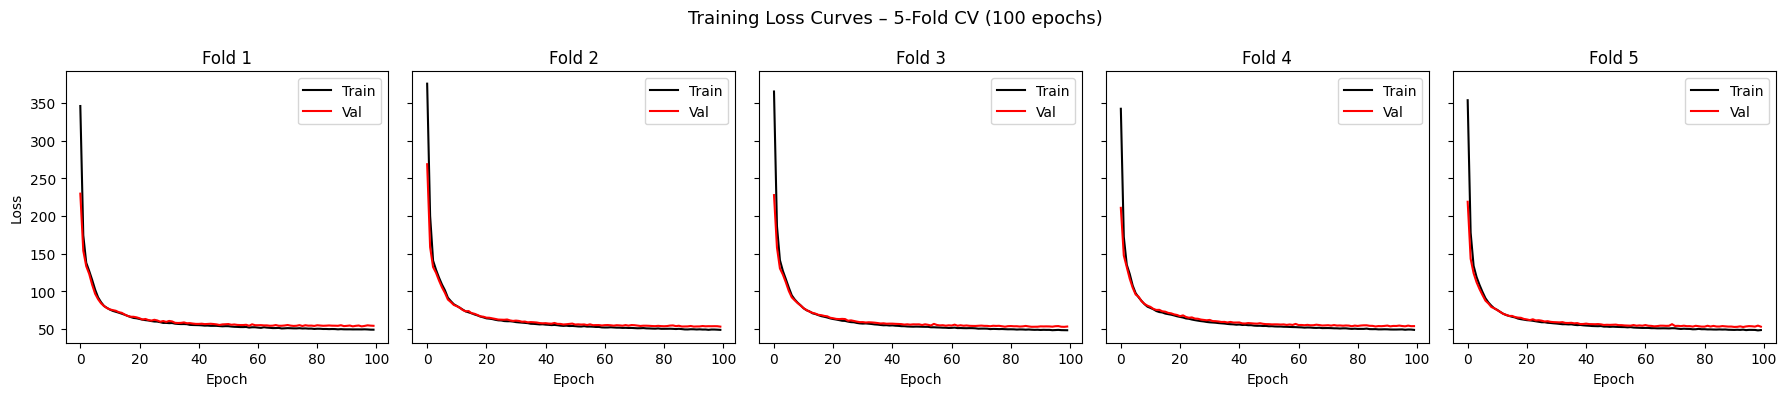

In [14]:
fig, axes = plt.subplots(1, n_splits, figsize=(18, 4), sharey=True)
for fold_idx, hist in enumerate(fold_histories):
    axes[fold_idx].plot(hist['loss'],     label='Train', color='black')
    axes[fold_idx].plot(hist['val_loss'], label='Val',   color='red')
    axes[fold_idx].set_title(f'Fold {fold_idx + 1}')
    axes[fold_idx].set_xlabel('Epoch')
    if fold_idx == 0:
        axes[fold_idx].set_ylabel('Loss')
    axes[fold_idx].legend()
plt.suptitle('Training Loss Curves – 5-Fold CV (100 epochs)', fontsize=13)
plt.tight_layout()
plt.savefig(filepath + 'training_loss_curves.png', dpi=150)
plt.show()

## Evaluation

**Run encoder on full dataset to get cluster probabilities**

In [15]:
print("Running encoder on full dataset...")
[z_mean_enc, z_log_var_enc, z_enc, mu_enc, c_enc, pi_enc, r_enc, cr_enc] = encoder.predict(
    [X, dummy_full, y], batch_size=batch_size, verbose=0)
print(f"c_enc shape: {c_enc.shape}  (n_days x cluster_number)")

Running encoder on full dataset...
c_enc shape: (6353, 5)  (n_days x cluster_number)


### Maximum-likelihood cluster assignment

In [16]:
final_labels = np.argmax(c_enc, axis=1).astype(float)
print(f"Unique cluster labels: {np.unique(final_labels.astype(int))}")
for k in range(cluster_number):
    n = (final_labels == k).sum()
    print(f"  Cluster {k}: {n} days  ({100*n/len(final_labels):.1f}%)")

Unique cluster labels: [0 1 2 3 4]
  Cluster 0: 1609 days  (25.3%)
  Cluster 1: 976 days  (15.4%)
  Cluster 2: 1153 days  (18.1%)
  Cluster 3: 837 days  (13.2%)
  Cluster 4: 1778 days  (28.0%)


### Cluster centres – re-order by precipitation amount

In [17]:
# Sum precipitation over all grid points for each day  →  1-D array
pr_total_daily = pr_spatial.sum(dim=['latitude', 'longitude']).values
# pr_spatial and final_labels must be the same length
assert len(pr_total_daily) == len(final_labels), (
    f"Length mismatch: pr_total_daily={len(pr_total_daily)}, "
    f"final_labels={len(final_labels)}")

precip_sum = (pd.DataFrame({'values': pr_total_daily, 'label': final_labels.astype(int)})
              .groupby('label')['values'].sum()
              .reset_index()
              .rename(columns={'label': 'index_old'})
              .sort_values('values', ascending=False)
              .reset_index(drop=True))
precip_sum['index_new'] = np.arange(len(precip_sum))

labels_reordered = final_labels.copy()
for i in range(len(final_labels)):
    new_label = precip_sum.loc[
        precip_sum['index_old'] == int(final_labels[i]), 'index_new'].values[0]
    labels_reordered[i] = new_label

print(precip_sum)

   index_old      values  index_new
0          3  40611528.0          0
1          2  26704420.0          1
2          0  17225030.0          2
3          1   7087679.5          3
4          4   7042325.5          4


### Save results

In [18]:
df = pd.DataFrame(data=c_enc)
df_reordered = df[precip_sum['index_old'].values.tolist()].copy()
df_reordered.columns = list(range(cluster_number))
df_reordered['label'] = labels_reordered

df['label'] = final_labels
df.to_csv(filepath + 'cluster_probabilities_' + str(cluster_number) + '.csv')
print("Cluster probabilities saved.")

Cluster probabilities saved.


In [19]:
z500_labels_preciporder = z500.assign_coords(label=('time', labels_reordered)) / weights
z500_labels             = z500.assign_coords(label=('time', final_labels))             / weights

means_preciporder = z500_labels_preciporder.groupby('label').mean()
means             = z500_labels.groupby('label').mean()

means_flat             = cf.reshape_data_for_clustering(means)
means_flat_preciporder = cf.reshape_data_for_clustering(means_preciporder)

pd.DataFrame(means_flat).to_csv(
    filepath + 'cluster_centers_' + str(cluster_number) + '.csv')
pd.DataFrame(means_flat_preciporder).to_csv(
    filepath + 'cluster_centers_' + str(cluster_number) + '_preciporder.csv')
print("Cluster centres saved.")

Cluster centres saved.


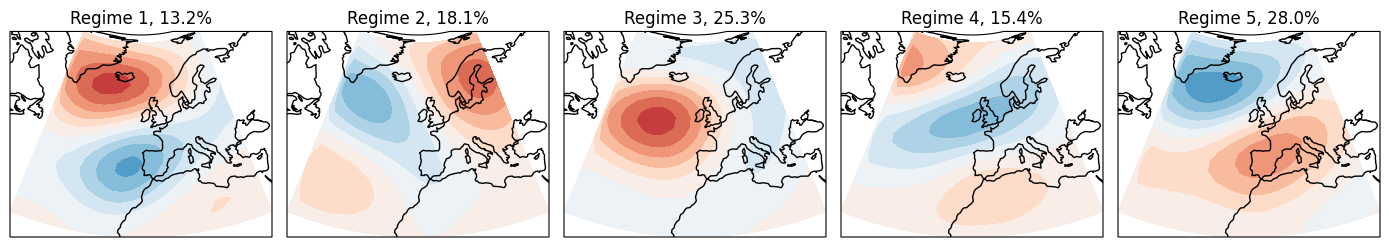

In [20]:
regime_names = [f'Regime {i+1}' for i in range(cluster_number)]

cluster_centers_vis = cf.visualise_contourplot(
    cluster_centers = means_preciporder,
    unit            = '[m]',
    regime_names    = regime_names,
    vmin            = -4, vmax = 4.5, steps = 0.5,
    color_scheme    = 'RdBu_r',
    labels_data     = X,
    labels          = labels_reordered,
    borders         = False,
    col_number      = cluster_number,
    projection      = ccrs.AlbersEqualArea(central_longitude=-10, central_latitude=50))

plt.savefig(filepath + 'cluster_centers_' + str(cluster_number) + '.png', dpi=150)
plt.show()

**Precipitation odds ratio**

c:\Users\Lenovo\Desktop\CMM-VAE-Morocco3\cmmvae_env\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


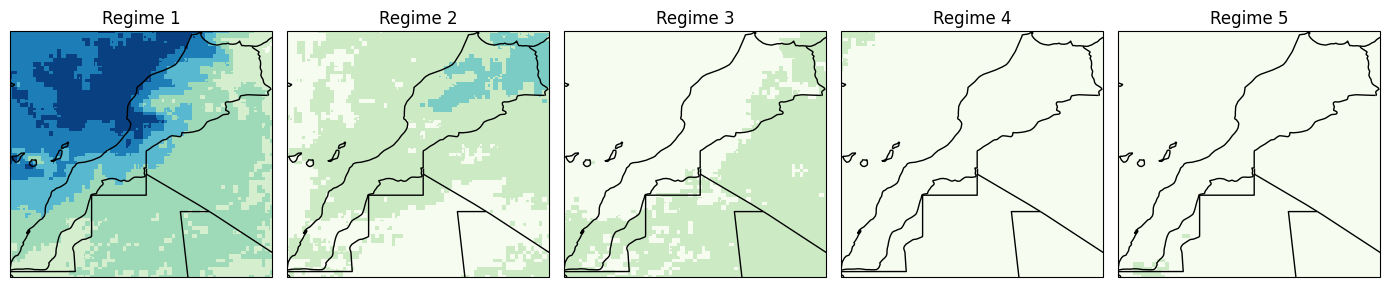

In [21]:
pr_qn95_ratio = cf.calculate_conditional_probability_change_label(
    threshold_matrix = threshold_qn95,
    labels           = labels_reordered,
    comparison       = 'ratio',
    shift_value      = 0)

pr_qn95_vis = cf.visualise_spatial_oddsratio(
    dataset_xarray = pr_qn95_ratio,
    unit           = '',
    color_scheme   = 'GnBu',
    vmin           = 0, vmax = 5, steps = 6,
    title          = 'Odds ratio – 95th percentile precipitation (MSWEP)',
    regime_names   = regime_names,
    borders        = True,
    projection     = ccrs.PlateCarree(central_longitude=0),
    col_number     = cluster_number)

plt.savefig(filepath + 'precip_odds_ratio_' + str(cluster_number) + '.png', dpi=150)
plt.show()

## Skill Scores

> **Testing note:** Brier Skill Scores computed from `out_of_fold_predictions` (K-Fold held-out data = purely unseen days) for a fair evaluation. Full-dataset scores via `c_enc` are also printed for comparison.

In [23]:
print("=== BSS on OUT-OF-FOLD (unseen test days) ===")
bss_95_test = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500      = cluster_number,
    z500_cluster_probabilities = out_of_fold_predictions,
    pr_spatial               = pr_spatial)
print(f"BSS 95th percentile (test): {bss_95_test:.4f}")

bss_cluster_test = sf.calculate_cluster_skill_score_probabilistic(
    cluster_number_pr          = 5,
    cluster_number_z500        = cluster_number,
    pr_cluster_labels          = np.array(pr_labels['labels']),
    z500_cluster_probabilities = out_of_fold_predictions)
print(f"BSS cluster (test):         {bss_cluster_test:.4f}")

bss_tercile_test = sf.calculate_tercile_skill_score_probabilistic(
    cluster_number_z500      = cluster_number,
    z500_cluster_probabilities = out_of_fold_predictions,
    pr_spatial               = pr_spatial)
print(f"BSS tercile (test, spatial mean): {float(bss_tercile_test.mean()):.4f}")
print(f"BSS tercile (test, spatial map shape): {bss_tercile_test.shape}")

print("\n=== BSS on FULL DATASET (c_enc, for reference) ===")
bss_95_full = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500      = cluster_number,
    z500_cluster_probabilities = c_enc,
    pr_spatial               = pr_spatial)
print(f"BSS 95th percentile (full): {bss_95_full:.4f}")

# Save results as a fresh CSV
df_scores = pd.DataFrame({
    'k':             [cluster_number],
    'bss_95_test':   [bss_95_test],
    'bss_cluster_test': [bss_cluster_test],
    'bss_tercile_test': [bss_tercile_test],
    'bss_95_full':   [bss_95_full],
    'best_fold':     [best_fold],
    'best_val_loss': [best_val_loss]
})
df_scores.to_csv(filepath + 'skill_score.csv', index=False)
print("\nSkill scores saved to skill_score.csv")

=== BSS on OUT-OF-FOLD (unseen test days) ===
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
BSS 95th percentile (test): 0.1641
BSS cluster (test):         0.1749
BSS tercile (test, spatial mean): 0.0691
BSS tercile (test, spatial map shape): (150, 160)

=== BSS on FULL DATASET (c_enc, for reference) ===
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
BSS 95th percentile (full): 0.2210

Skill scores saved to skill_score.csv


In [25]:
# CORRECTED case-by-case verification
# Use r_enc — the model's DIRECT precipitation cluster prediction

[_, _, _, _, c_enc_full, _, r_enc_full, _] = encoder.predict(
    [X, dummy_full, y], batch_size=batch_size, verbose=0)

predicted_precip = np.argmax(r_enc_full, axis=1)   # model's precip prediction
real_precip      = np.argmax(y, axis=1)             # real MSWEP cluster

accuracy = (predicted_precip == real_precip).mean()
print(f"Precipitation Cluster Accuracy: {accuracy*100:.1f}%")
print(f"({(predicted_precip == real_precip).sum()} correct out of {len(real_precip)} days)")
print(f"Random baseline would be: {100/pr_cluster_number:.1f}%")

# Table
confidence  = r_enc_full.max(axis=1)
correct_mask  = (predicted_precip == real_precip)
correct_idx   = np.where(correct_mask)[0][np.argsort(confidence[correct_mask])[-3:]]
incorrect_idx = np.where(~correct_mask)[0][np.argsort(confidence[~correct_mask])[-3:]]

print(f"\n{'Day':>6} | {'Date':>12} | {'Real Cluster':>12} | {'Predicted':>10} | {'Confidence':>12} | {'Result':>8}")
print("-" * 75)
for idx, verdict in zip(
    np.concatenate([correct_idx, incorrect_idx]),
    ['CORRECT']*3 + ['WRONG']*3):
    date = str(pr_spatial.time.values[idx])[:10]
    print(f"{idx:>6} | {date:>12} | {real_precip[idx]:>12} | {predicted_precip[idx]:>10} | {confidence[idx]:>11.1%} | {verdict:>8}")


Precipitation Cluster Accuracy: 92.3%
(5866 correct out of 6353 days)
Random baseline would be: 20.0%

   Day |         Date | Real Cluster |  Predicted |   Confidence |   Result
---------------------------------------------------------------------------
  1825 |   1991-01-11 |            0 |          0 |      100.0% |  CORRECT
  5901 |   2018-01-03 |            0 |          0 |      100.0% |  CORRECT
  3058 |   1999-02-03 |            0 |          0 |      100.0% |  CORRECT
  5937 |   2018-02-08 |            2 |          4 |      100.0% |    WRONG
  3677 |   2003-02-17 |            0 |          4 |      100.0% |    WRONG
  5536 |   2015-11-02 |            4 |          0 |      100.0% |    WRONG


c:\Users\Lenovo\Desktop\CMM-VAE-Morocco3\cmmvae_env\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\Lenovo\Desktop\CMM-VAE-Morocco3\cmmvae_env\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


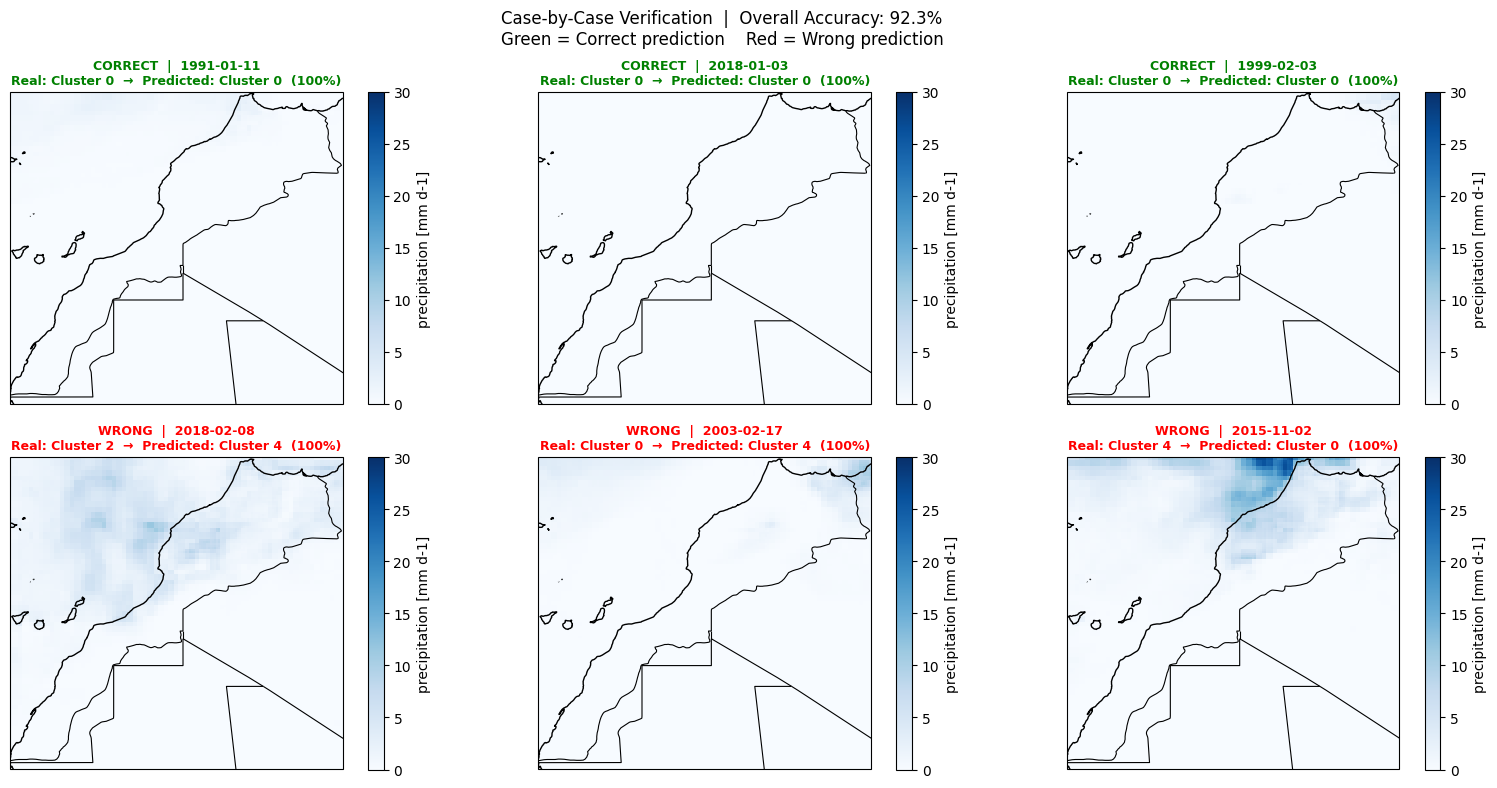

Plot saved.


In [26]:
import cartopy.feature as cfeature

case_indices = np.concatenate([correct_idx, incorrect_idx])
case_labels  = ['CORRECT'] * 3 + ['WRONG'] * 3

fig, axes = plt.subplots(2, 3, figsize=(16, 8),
                          subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for ax_idx, (idx, verdict) in enumerate(zip(case_indices, case_labels)):
    date = str(pr_spatial.time.values[idx])[:10]
    real = real_precip[idx]
    pred = predicted_precip[idx]
    conf = r_enc_full[idx].max()

    pr_spatial[idx].plot(
        ax=axes[ax_idx],
        cmap='Blues',
        transform=ccrs.PlateCarree(),
        add_colorbar=True,
        vmin=0, vmax=30)

    axes[ax_idx].coastlines(resolution='10m')
    axes[ax_idx].add_feature(cfeature.BORDERS, linewidth=0.8)
    axes[ax_idx].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

    color = 'green' if verdict == 'CORRECT' else 'red'
    axes[ax_idx].set_title(
        f"{verdict}  |  {date}\nReal: Cluster {real}  →  Predicted: Cluster {pred}  ({conf:.0%})",
        color=color, fontsize=9, fontweight='bold')

plt.suptitle(
    f"Case-by-Case Verification  |  Overall Accuracy: {accuracy*100:.1f}%\n"
    "Green = Correct prediction    Red = Wrong prediction",
    fontsize=12)
plt.tight_layout()
plt.savefig("results/cmmvae_mswep/case_verification.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")
